0


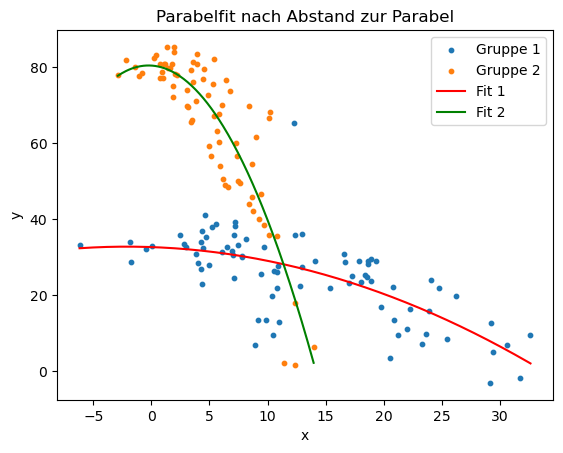

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

t = np.linspace(0, 20, 400)
g = 9.81

y0_1 = 80
y0_2 = 35
v0_1 = 5
angle_1 = 60

a1 = np.radians(angle_1)
x1 = v0_1 * np.cos(a1) * t
y1 = y0_1 + v0_1 * np.sin(a1) * t - 0.5 * g * t**2


v0_2 = 10
angle_2 = 35

a2 = np.radians(angle_2)
x2 = v0_2 * np.cos(a2) * t
y2 = y0_2 + v0_2 * np.sin(a2) * t - 0.5 * g * t**2

#positive y-werte
mask1 = y1 >= 0
x1 = x1[mask1]
y1 = y1[mask1]

mask2 = y2 >= 0
x2 = x2[mask2]
y2 = y2[mask2]

#rauschen
noise_level = 2
noise_level_y = 3
noise_level_2 = 4

x1_noisy = x1 + np.random.normal(0, noise_level, len(x1))
y1_noisy = y1 + np.random.normal(0, noise_level_y, len(y1))

x2_noisy = x2 + np.random.normal(0, noise_level_2, len(x2))
y2_noisy = y2 + np.random.normal(0, noise_level_2, len(y2))

#messwerte mischen
points_x = np.concatenate([x1_noisy, x2_noisy])
points_y = np.concatenate([y1_noisy, y2_noisy])


indices = np.random.permutation(len(points_x))

points_x = points_x[indices]
points_y = points_y[indices]

#clustering
points_for_kmeans = points_x.reshape(-1, 1)


kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(points_for_kmeans)

#iterative einordnung
for _ in range(20):

    old_labels = labels.copy()
    
    x_group1 = points_x[labels == 0]
    y_group1 = points_y[labels == 0]

    x_group2 = points_x[labels == 1]
    y_group2 = points_y[labels == 1]


    coef1 = np.polyfit(x_group1, y_group1, 2)
    coef2 = np.polyfit(x_group2, y_group2, 2)

    poly1 = np.poly1d(coef1)
    poly2 = np.poly1d(coef2)


    d1 = np.abs(points_y - poly1(points_x))
    d2 = np.abs(points_y - poly2(points_x))

    labels = (d2 < d1).astype(int)

    #abbruch berechnen wenn änderung unter 1% liegt
    changes = np.sum(labels != old_labels)
    relative_change = changes / len(labels)
    if relative_change < 0.01:
        break

x_group1 = points_x[labels == 0]
y_group1 = points_y[labels == 0]

x_group2 = points_x[labels == 1]
y_group2 = points_y[labels == 1]


coef1 = np.polyfit(x_group1, y_group1, 2)
coef2 = np.polyfit(x_group2, y_group2, 2)

poly1 = np.poly1d(coef1)
poly2 = np.poly1d(coef2)


x_fit1 = np.linspace(min(x_group1), max(x_group1), 200)
x_fit2 = np.linspace(min(x_group2), max(x_group2), 200)

y_fit1 = poly1(x_fit1)
y_fit2 = poly2(x_fit2)

#plotting
plt.scatter(x_group1, y_group1, s=10, label='Gruppe 1')
plt.scatter(x_group2, y_group2, s=10, label='Gruppe 2')
plt.plot(x_fit1, y_fit1, label='Fit 1', color='red')
plt.plot(x_fit2, y_fit2, label='Fit 2', color='green')
print(changes)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabelfit nach Abstand zur Parabel")
plt.legend()
plt.show()

1


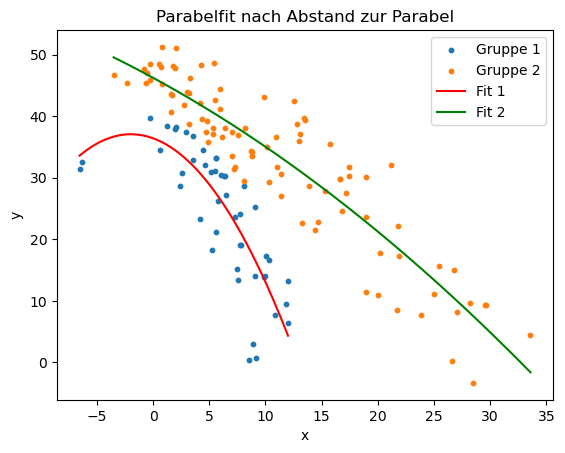

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

t = np.linspace(0, 20, 400)
g = 9.81

y0_1 = 45
y0_2 = 35
v0_1 = 5
angle_1 = 60

a1 = np.radians(angle_1)
x1 = v0_1 * np.cos(a1) * t
y1 = y0_1 + v0_1 * np.sin(a1) * t - 0.5 * g * t**2


v0_2 = 10
angle_2 = 35

a2 = np.radians(angle_2)
x2 = v0_2 * np.cos(a2) * t
y2 = y0_2 + v0_2 * np.sin(a2) * t - 0.5 * g * t**2

#positive y-werte
mask1 = y1 >= 0
x1 = x1[mask1]
y1 = y1[mask1]

mask2 = y2 >= 0
x2 = x2[mask2]
y2 = y2[mask2]

#rauschen
noise_level = 2
noise_level_y = 3
noise_level_2 = 4

x1_noisy = x1 + np.random.normal(0, noise_level, len(x1))
y1_noisy = y1 + np.random.normal(0, noise_level_y, len(y1))

x2_noisy = x2 + np.random.normal(0, noise_level_2, len(x2))
y2_noisy = y2 + np.random.normal(0, noise_level_2, len(y2))

#messwerte mischen
points_x = np.concatenate([x1_noisy, x2_noisy])
points_y = np.concatenate([y1_noisy, y2_noisy])


indices = np.random.permutation(len(points_x))

points_x = points_x[indices]
points_y = points_y[indices]

#clustering
points_for_kmeans = points_x.reshape(-1, 1)


kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(points_for_kmeans)

#iterative einordnung
for _ in range(100):

    old_labels = labels.copy()
    
    x_group1 = points_x[labels == 0]
    y_group1 = points_y[labels == 0]

    x_group2 = points_x[labels == 1]
    y_group2 = points_y[labels == 1]


    coef1 = np.polyfit(x_group1, y_group1, 2)
    coef2 = np.polyfit(x_group2, y_group2, 2)

    poly1 = np.poly1d(coef1)
    poly2 = np.poly1d(coef2)


    d1 = np.abs(points_y - poly1(points_x))
    d2 = np.abs(points_y - poly2(points_x))

    labels = (d2 < d1).astype(int)

    #abbruch berechnen wenn änderung unter 1% liegt
    changes = np.sum(labels != old_labels)
    relative_change = changes / len(labels)
    if relative_change < 0.01:
        break

x_group1 = points_x[labels == 0]
y_group1 = points_y[labels == 0]

x_group2 = points_x[labels == 1]
y_group2 = points_y[labels == 1]


coef1 = np.polyfit(x_group1, y_group1, 2)
coef2 = np.polyfit(x_group2, y_group2, 2)

poly1 = np.poly1d(coef1)
poly2 = np.poly1d(coef2)


x_fit1 = np.linspace(min(x_group1), max(x_group1), 200)
x_fit2 = np.linspace(min(x_group2), max(x_group2), 200)

y_fit1 = poly1(x_fit1)
y_fit2 = poly2(x_fit2)

#plotting
plt.scatter(x_group1, y_group1, s=10, label='Gruppe 1')
plt.scatter(x_group2, y_group2, s=10, label='Gruppe 2')
plt.plot(x_fit1, y_fit1, label='Fit 1', color='red')
plt.plot(x_fit2, y_fit2, label='Fit 2', color='green')
print(changes)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabelfit nach Abstand zur Parabel")
plt.legend()
plt.show()

1


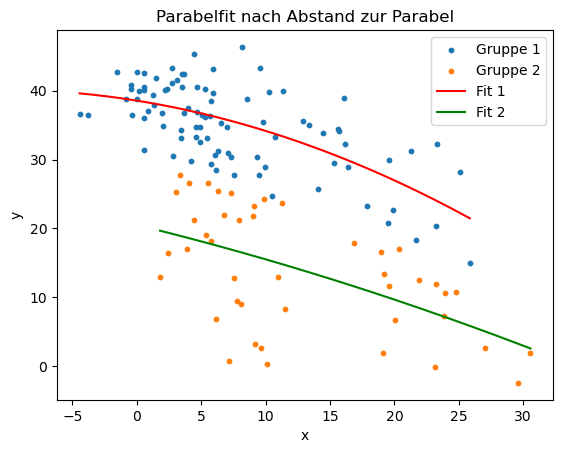

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

t = np.linspace(0, 20, 400)
g = 9.81

y0_1 = 40
y0_2 = 35
v0_1 = 5
angle_1 = 60

a1 = np.radians(angle_1)
x1 = v0_1 * np.cos(a1) * t
y1 = y0_1 + v0_1 * np.sin(a1) * t - 0.5 * g * t**2


v0_2 = 10
angle_2 = 35

a2 = np.radians(angle_2)
x2 = v0_2 * np.cos(a2) * t
y2 = y0_2 + v0_2 * np.sin(a2) * t - 0.5 * g * t**2

#positive y-werte
mask1 = y1 >= 0
x1 = x1[mask1]
y1 = y1[mask1]

mask2 = y2 >= 0
x2 = x2[mask2]
y2 = y2[mask2]

#rauschen
noise_level = 2
noise_level_y = 3
noise_level_2 = 4

x1_noisy = x1 + np.random.normal(0, noise_level, len(x1))
y1_noisy = y1 + np.random.normal(0, noise_level_y, len(y1))

x2_noisy = x2 + np.random.normal(0, noise_level_2, len(x2))
y2_noisy = y2 + np.random.normal(0, noise_level_2, len(y2))

#messwerte mischen
points_x = np.concatenate([x1_noisy, x2_noisy])
points_y = np.concatenate([y1_noisy, y2_noisy])


indices = np.random.permutation(len(points_x))

points_x = points_x[indices]
points_y = points_y[indices]

#clustering
points_for_kmeans = points_x.reshape(-1, 1)


kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(points_for_kmeans)

#iterative einordnung
for _ in range(100):

    old_labels = labels.copy()
    
    x_group1 = points_x[labels == 0]
    y_group1 = points_y[labels == 0]

    x_group2 = points_x[labels == 1]
    y_group2 = points_y[labels == 1]


    coef1 = np.polyfit(x_group1, y_group1, 2)
    coef2 = np.polyfit(x_group2, y_group2, 2)

    poly1 = np.poly1d(coef1)
    poly2 = np.poly1d(coef2)


    d1 = np.abs(points_y - poly1(points_x))
    d2 = np.abs(points_y - poly2(points_x))

    labels = (d2 < d1).astype(int)

    #abbruch berechnen wenn änderung unter 1% liegt
    changes = np.sum(labels != old_labels)
    relative_change = changes / len(labels)
    if relative_change < 0.01:
        break

x_group1 = points_x[labels == 0]
y_group1 = points_y[labels == 0]

x_group2 = points_x[labels == 1]
y_group2 = points_y[labels == 1]


coef1 = np.polyfit(x_group1, y_group1, 2)
coef2 = np.polyfit(x_group2, y_group2, 2)

poly1 = np.poly1d(coef1)
poly2 = np.poly1d(coef2)


x_fit1 = np.linspace(min(x_group1), max(x_group1), 200)
x_fit2 = np.linspace(min(x_group2), max(x_group2), 200)

y_fit1 = poly1(x_fit1)
y_fit2 = poly2(x_fit2)

#plotting
plt.scatter(x_group1, y_group1, s=10, label='Gruppe 1')
plt.scatter(x_group2, y_group2, s=10, label='Gruppe 2')
plt.plot(x_fit1, y_fit1, label='Fit 1', color='red')
plt.plot(x_fit2, y_fit2, label='Fit 2', color='green')
print(changes)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabelfit nach Abstand zur Parabel")
plt.legend()
plt.show()

0
0.0


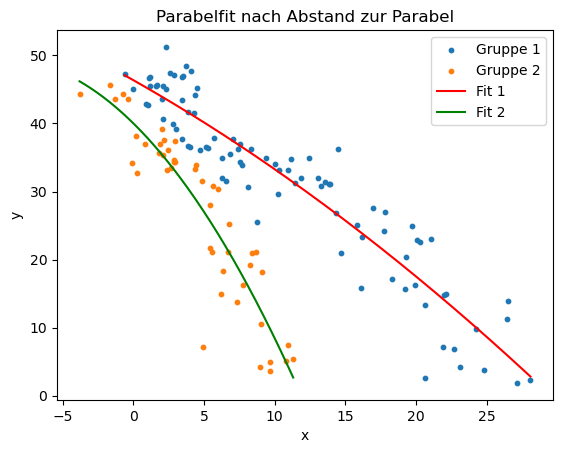

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

t = np.linspace(0, 20, 400)
g = 9.81

y0_1 = 45
y0_2 = 35
v0_1 = 5
angle_1 = 60

a1 = np.radians(angle_1)
x1 = v0_1 * np.cos(a1) * t
y1 = y0_1 + v0_1 * np.sin(a1) * t - 0.5 * g * t**2


v0_2 = 10
angle_2 = 35

a2 = np.radians(angle_2)
x2 = v0_2 * np.cos(a2) * t
y2 = y0_2 + v0_2 * np.sin(a2) * t - 0.5 * g * t**2

#positive y-werte
mask1 = y1 >= 0
x1 = x1[mask1]
y1 = y1[mask1]

mask2 = y2 >= 0
x2 = x2[mask2]
y2 = y2[mask2]

#rauschen
noise_level = 2
noise_level_y = 2
noise_level_2 = 2

x1_noisy = x1 + np.random.normal(0, noise_level, len(x1))
y1_noisy = y1 + np.random.normal(0, noise_level_y, len(y1))

x2_noisy = x2 + np.random.normal(0, noise_level_2, len(x2))
y2_noisy = y2 + np.random.normal(0, noise_level_2, len(y2))

#messwerte mischen
points_x = np.concatenate([x1_noisy, x2_noisy])
points_y = np.concatenate([y1_noisy, y2_noisy])


indices = np.random.permutation(len(points_x))

points_x = points_x[indices]
points_y = points_y[indices]

#clustering
points_for_kmeans = points_x.reshape(-1, 1)


kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(points_for_kmeans)

#iterative einordnung
for _ in range(100):

    old_labels = labels.copy()
    
    x_group1 = points_x[labels == 0]
    y_group1 = points_y[labels == 0]

    x_group2 = points_x[labels == 1]
    y_group2 = points_y[labels == 1]


    coef1 = np.polyfit(x_group1, y_group1, 2)
    coef2 = np.polyfit(x_group2, y_group2, 2)

    poly1 = np.poly1d(coef1)
    poly2 = np.poly1d(coef2)


    d1 = np.abs(points_y - poly1(points_x))
    d2 = np.abs(points_y - poly2(points_x))

    labels = (d2 < d1).astype(int)

    #abbruch berechnen wenn änderung unter 1% liegt
    changes = np.sum(labels != old_labels)
    relative_change = changes / len(labels)
    if relative_change < 0.01:
        break

x_group1 = points_x[labels == 0]
y_group1 = points_y[labels == 0]

x_group2 = points_x[labels == 1]
y_group2 = points_y[labels == 1]


coef1 = np.polyfit(x_group1, y_group1, 2)
coef2 = np.polyfit(x_group2, y_group2, 2)

poly1 = np.poly1d(coef1)
poly2 = np.poly1d(coef2)


x_fit1 = np.linspace(min(x_group1), max(x_group1), 200)
x_fit2 = np.linspace(min(x_group2), max(x_group2), 200)

y_fit1 = poly1(x_fit1)
y_fit2 = poly2(x_fit2)

#plotting
plt.scatter(x_group1, y_group1, s=10, label='Gruppe 1')
plt.scatter(x_group2, y_group2, s=10, label='Gruppe 2')
plt.plot(x_fit1, y_fit1, label='Fit 1', color='red')
plt.plot(x_fit2, y_fit2, label='Fit 2', color='green')
print(changes)
print(relative_change)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabelfit nach Abstand zur Parabel")
plt.legend()
plt.show()

1
0.0072992700729927005


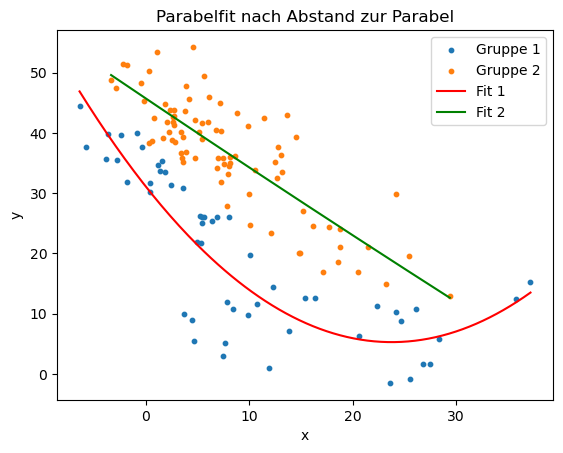

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

t = np.linspace(0, 20, 400)
g = 9.81

y0_1 = 45
y0_2 = 35
v0_1 = 5
angle_1 = 60

a1 = np.radians(angle_1)
x1 = v0_1 * np.cos(a1) * t
y1 = y0_1 + v0_1 * np.sin(a1) * t - 0.5 * g * t**2


v0_2 = 10
angle_2 = 35

a2 = np.radians(angle_2)
x2 = v0_2 * np.cos(a2) * t
y2 = y0_2 + v0_2 * np.sin(a2) * t - 0.5 * g * t**2

#positive y-werte
mask1 = y1 >= 0
x1 = x1[mask1]
y1 = y1[mask1]

mask2 = y2 >= 0
x2 = x2[mask2]
y2 = y2[mask2]

#rauschen
noise_level = 3
noise_level_y = 4
noise_level_2 = 5

x1_noisy = x1 + np.random.normal(0, noise_level, len(x1))
y1_noisy = y1 + np.random.normal(0, noise_level_y, len(y1))

x2_noisy = x2 + np.random.normal(0, noise_level_2, len(x2))
y2_noisy = y2 + np.random.normal(0, noise_level_2, len(y2))

#messwerte mischen
points_x = np.concatenate([x1_noisy, x2_noisy])
points_y = np.concatenate([y1_noisy, y2_noisy])


indices = np.random.permutation(len(points_x))

points_x = points_x[indices]
points_y = points_y[indices]

#clustering
points_for_kmeans = points_x.reshape(-1, 1)


kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(points_for_kmeans)

#iterative einordnung
for _ in range(100):

    old_labels = labels.copy()
    
    x_group1 = points_x[labels == 0]
    y_group1 = points_y[labels == 0]

    x_group2 = points_x[labels == 1]
    y_group2 = points_y[labels == 1]


    coef1 = np.polyfit(x_group1, y_group1, 2)
    coef2 = np.polyfit(x_group2, y_group2, 2)

    poly1 = np.poly1d(coef1)
    poly2 = np.poly1d(coef2)


    d1 = np.abs(points_y - poly1(points_x))
    d2 = np.abs(points_y - poly2(points_x))

    labels = (d2 < d1).astype(int)

    #abbruch berechnen wenn änderung unter 1% liegt
    changes = np.sum(labels != old_labels)
    relative_change = changes / len(labels)
    if relative_change < 0.01:
        break

x_group1 = points_x[labels == 0]
y_group1 = points_y[labels == 0]

x_group2 = points_x[labels == 1]
y_group2 = points_y[labels == 1]


coef1 = np.polyfit(x_group1, y_group1, 2)
coef2 = np.polyfit(x_group2, y_group2, 2)

poly1 = np.poly1d(coef1)
poly2 = np.poly1d(coef2)


x_fit1 = np.linspace(min(x_group1), max(x_group1), 200)
x_fit2 = np.linspace(min(x_group2), max(x_group2), 200)

y_fit1 = poly1(x_fit1)
y_fit2 = poly2(x_fit2)

#plotting
plt.scatter(x_group1, y_group1, s=10, label='Gruppe 1')
plt.scatter(x_group2, y_group2, s=10, label='Gruppe 2')
plt.plot(x_fit1, y_fit1, label='Fit 1', color='red')
plt.plot(x_fit2, y_fit2, label='Fit 2', color='green')
print(changes)
print(relative_change)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabelfit nach Abstand zur Parabel")
plt.legend()
plt.show()

1
0.0072992700729927005


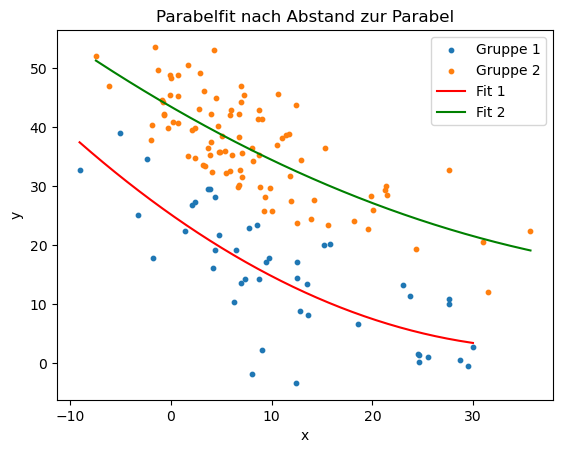

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

t = np.linspace(0, 20, 400)
g = 9.81

y0_1 = 45
y0_2 = 35
v0_1 = 5
angle_1 = 60

a1 = np.radians(angle_1)
x1 = v0_1 * np.cos(a1) * t
y1 = y0_1 + v0_1 * np.sin(a1) * t - 0.5 * g * t**2


v0_2 = 10
angle_2 = 35

a2 = np.radians(angle_2)
x2 = v0_2 * np.cos(a2) * t
y2 = y0_2 + v0_2 * np.sin(a2) * t - 0.5 * g * t**2

#positive y-werte
mask1 = y1 >= 0
x1 = x1[mask1]
y1 = y1[mask1]

mask2 = y2 >= 0
x2 = x2[mask2]
y2 = y2[mask2]

#rauschen
noise_level = 4
noise_level_y = 4
noise_level_2 = 5

x1_noisy = x1 + np.random.normal(0, noise_level, len(x1))
y1_noisy = y1 + np.random.normal(0, noise_level_y, len(y1))

x2_noisy = x2 + np.random.normal(0, noise_level_2, len(x2))
y2_noisy = y2 + np.random.normal(0, noise_level_2, len(y2))

#messwerte mischen
points_x = np.concatenate([x1_noisy, x2_noisy])
points_y = np.concatenate([y1_noisy, y2_noisy])


indices = np.random.permutation(len(points_x))

points_x = points_x[indices]
points_y = points_y[indices]

#clustering
points_for_kmeans = points_x.reshape(-1, 1)


kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(points_for_kmeans)

#iterative einordnung
for _ in range(100):

    old_labels = labels.copy()
    
    x_group1 = points_x[labels == 0]
    y_group1 = points_y[labels == 0]

    x_group2 = points_x[labels == 1]
    y_group2 = points_y[labels == 1]


    coef1 = np.polyfit(x_group1, y_group1, 2)
    coef2 = np.polyfit(x_group2, y_group2, 2)

    poly1 = np.poly1d(coef1)
    poly2 = np.poly1d(coef2)


    d1 = np.abs(points_y - poly1(points_x))
    d2 = np.abs(points_y - poly2(points_x))

    labels = (d2 < d1).astype(int)

    #abbruch berechnen wenn änderung unter 1% liegt
    changes = np.sum(labels != old_labels)
    relative_change = changes / len(labels)
    if relative_change < 0.01:
        break

x_group1 = points_x[labels == 0]
y_group1 = points_y[labels == 0]

x_group2 = points_x[labels == 1]
y_group2 = points_y[labels == 1]


coef1 = np.polyfit(x_group1, y_group1, 2)
coef2 = np.polyfit(x_group2, y_group2, 2)

poly1 = np.poly1d(coef1)
poly2 = np.poly1d(coef2)


x_fit1 = np.linspace(min(x_group1), max(x_group1), 200)
x_fit2 = np.linspace(min(x_group2), max(x_group2), 200)

y_fit1 = poly1(x_fit1)
y_fit2 = poly2(x_fit2)

#plotting
plt.scatter(x_group1, y_group1, s=10, label='Gruppe 1')
plt.scatter(x_group2, y_group2, s=10, label='Gruppe 2')
plt.plot(x_fit1, y_fit1, label='Fit 1', color='red')
plt.plot(x_fit2, y_fit2, label='Fit 2', color='green')
print(changes)
print(relative_change)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabelfit nach Abstand zur Parabel")
plt.legend()
plt.show()

0
0.0


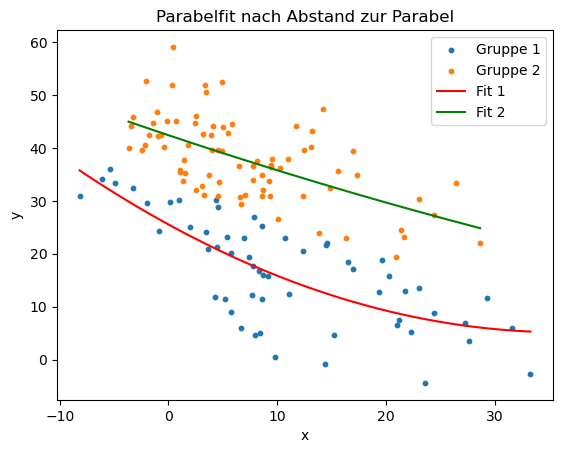

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

t = np.linspace(0, 20, 400)
g = 9.81

y0_1 = 45
y0_2 = 35
v0_1 = 5
angle_1 = 60

a1 = np.radians(angle_1)
x1 = v0_1 * np.cos(a1) * t
y1 = y0_1 + v0_1 * np.sin(a1) * t - 0.5 * g * t**2


v0_2 = 10
angle_2 = 35

a2 = np.radians(angle_2)
x2 = v0_2 * np.cos(a2) * t
y2 = y0_2 + v0_2 * np.sin(a2) * t - 0.5 * g * t**2

#positive y-werte
mask1 = y1 >= 0
x1 = x1[mask1]
y1 = y1[mask1]

mask2 = y2 >= 0
x2 = x2[mask2]
y2 = y2[mask2]

#rauschen
noise_level = 3
noise_level_y = 6
noise_level_2 = 5

x1_noisy = x1 + np.random.normal(0, noise_level, len(x1))
y1_noisy = y1 + np.random.normal(0, noise_level_y, len(y1))

x2_noisy = x2 + np.random.normal(0, noise_level_2, len(x2))
y2_noisy = y2 + np.random.normal(0, noise_level_2, len(y2))

#messwerte mischen
points_x = np.concatenate([x1_noisy, x2_noisy])
points_y = np.concatenate([y1_noisy, y2_noisy])


indices = np.random.permutation(len(points_x))

points_x = points_x[indices]
points_y = points_y[indices]

#clustering
points_for_kmeans = points_x.reshape(-1, 1)


kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(points_for_kmeans)

#iterative einordnung
for _ in range(100):

    old_labels = labels.copy()
    
    x_group1 = points_x[labels == 0]
    y_group1 = points_y[labels == 0]

    x_group2 = points_x[labels == 1]
    y_group2 = points_y[labels == 1]


    coef1 = np.polyfit(x_group1, y_group1, 2)
    coef2 = np.polyfit(x_group2, y_group2, 2)

    poly1 = np.poly1d(coef1)
    poly2 = np.poly1d(coef2)


    d1 = np.abs(points_y - poly1(points_x))
    d2 = np.abs(points_y - poly2(points_x))

    labels = (d2 < d1).astype(int)

    #abbruch berechnen wenn änderung unter 1% liegt
    changes = np.sum(labels != old_labels)
    relative_change = changes / len(labels)
    if relative_change < 0.01:
        break

x_group1 = points_x[labels == 0]
y_group1 = points_y[labels == 0]

x_group2 = points_x[labels == 1]
y_group2 = points_y[labels == 1]


coef1 = np.polyfit(x_group1, y_group1, 2)
coef2 = np.polyfit(x_group2, y_group2, 2)

poly1 = np.poly1d(coef1)
poly2 = np.poly1d(coef2)


x_fit1 = np.linspace(min(x_group1), max(x_group1), 200)
x_fit2 = np.linspace(min(x_group2), max(x_group2), 200)

y_fit1 = poly1(x_fit1)
y_fit2 = poly2(x_fit2)

#plotting
plt.scatter(x_group1, y_group1, s=10, label='Gruppe 1')
plt.scatter(x_group2, y_group2, s=10, label='Gruppe 2')
plt.plot(x_fit1, y_fit1, label='Fit 1', color='red')
plt.plot(x_fit2, y_fit2, label='Fit 2', color='green')
print(changes)
print(relative_change)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabelfit nach Abstand zur Parabel")
plt.legend()
plt.show()

1
0.0072992700729927005


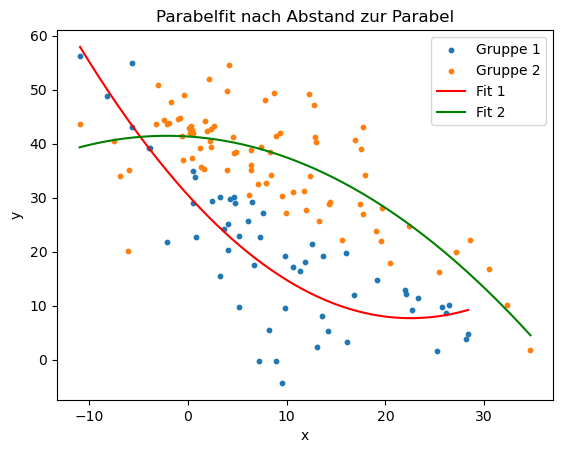

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

t = np.linspace(0, 20, 400)
g = 9.81

y0_1 = 45
y0_2 = 35
v0_1 = 5
angle_1 = 60

a1 = np.radians(angle_1)
x1 = v0_1 * np.cos(a1) * t
y1 = y0_1 + v0_1 * np.sin(a1) * t - 0.5 * g * t**2


v0_2 = 10
angle_2 = 35

a2 = np.radians(angle_2)
x2 = v0_2 * np.cos(a2) * t
y2 = y0_2 + v0_2 * np.sin(a2) * t - 0.5 * g * t**2

#positive y-werte
mask1 = y1 >= 0
x1 = x1[mask1]
y1 = y1[mask1]

mask2 = y2 >= 0
x2 = x2[mask2]
y2 = y2[mask2]

#rauschen
noise_level = 5
noise_level_y = 5
noise_level_2 = 5

x1_noisy = x1 + np.random.normal(0, noise_level, len(x1))
y1_noisy = y1 + np.random.normal(0, noise_level_y, len(y1))

x2_noisy = x2 + np.random.normal(0, noise_level_2, len(x2))
y2_noisy = y2 + np.random.normal(0, noise_level_2, len(y2))

#messwerte mischen
points_x = np.concatenate([x1_noisy, x2_noisy])
points_y = np.concatenate([y1_noisy, y2_noisy])


indices = np.random.permutation(len(points_x))

points_x = points_x[indices]
points_y = points_y[indices]

#clustering
points_for_kmeans = points_x.reshape(-1, 1)


kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(points_for_kmeans)

#iterative einordnung
for _ in range(100):

    old_labels = labels.copy()
    
    x_group1 = points_x[labels == 0]
    y_group1 = points_y[labels == 0]

    x_group2 = points_x[labels == 1]
    y_group2 = points_y[labels == 1]


    coef1 = np.polyfit(x_group1, y_group1, 2)
    coef2 = np.polyfit(x_group2, y_group2, 2)

    poly1 = np.poly1d(coef1)
    poly2 = np.poly1d(coef2)


    d1 = np.abs(points_y - poly1(points_x))
    d2 = np.abs(points_y - poly2(points_x))

    labels = (d2 < d1).astype(int)

    #abbruch berechnen wenn änderung unter 1% liegt
    changes = np.sum(labels != old_labels)
    relative_change = changes / len(labels)
    if relative_change < 0.01:
        break

x_group1 = points_x[labels == 0]
y_group1 = points_y[labels == 0]

x_group2 = points_x[labels == 1]
y_group2 = points_y[labels == 1]


coef1 = np.polyfit(x_group1, y_group1, 2)
coef2 = np.polyfit(x_group2, y_group2, 2)

poly1 = np.poly1d(coef1)
poly2 = np.poly1d(coef2)


x_fit1 = np.linspace(min(x_group1), max(x_group1), 200)
x_fit2 = np.linspace(min(x_group2), max(x_group2), 200)

y_fit1 = poly1(x_fit1)
y_fit2 = poly2(x_fit2)

#plotting
plt.scatter(x_group1, y_group1, s=10, label='Gruppe 1')
plt.scatter(x_group2, y_group2, s=10, label='Gruppe 2')
plt.plot(x_fit1, y_fit1, label='Fit 1', color='red')
plt.plot(x_fit2, y_fit2, label='Fit 2', color='green')
print(changes)
print(relative_change)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parabelfit nach Abstand zur Parabel")
plt.legend()
plt.show()